In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("cashflow_v2.db")
conn.row_factory = sqlite3.Row

conn.execute("""
    CREATE TABLE IF NOT EXISTS client (
        client_id           TEXT PRIMARY KEY,
        full_name           TEXT NOT NULL,
        birth_date          TEXT NOT NULL,
        industry             TEXT NOT NULL,
        registration_date       TEXT NOT NULL
    )
""")

conn.execute("""
    CREATE TABLE IF NOT EXISTS account (
        account_id        TEXT PRIMARY KEY,
        client_id         TEXT NOT NULL REFERENCES client(client_id),
        opening_date          TEXT NOT NULL,
        current_balance   NUMERIC NOT NULL DEFAULT 0
    )
""")

conn.execute("""
    CREATE TABLE IF NOT EXISTS payment_transaction (
        transaction_id   TEXT PRIMARY KEY,
        account_id       TEXT NOT NULL REFERENCES account(account_id),
        category_id      INTEGER,
        date              TEXT NOT NULL,
        amount             NUMERIC NOT NULL,
        direction           TEXT NOT NULL,
        counterparty          TEXT,
        payment_method          TEXT
    )
""")

conn.execute("INSERT OR REPLACE INTO client VALUES (?, ?, ?, ?, ?)",
             ("client_1", "Дарья Соколова", "2002-04-12", "HoReCa", "2026-03-15"))
conn.execute("INSERT OR REPLACE INTO account VALUES (?, ?, ?, ?)",
             ("account_1", "client_1", "2026-03-15", 18000))


conn.commit()
print("База готова")

База готова


In [2]:
conn.execute("DELETE FROM payment_transaction")
conn.commit()

df = None
for sep in [",", ";"]:
    for encoding in ["utf-8", "utf-8-sig", "cp1251", "mac_cyrillic"]:
        try:
            df = pd.read_csv("alfa.csv", sep=sep, encoding=encoding)
            if "transaction_id" in df.columns:
                print(f"Файл прочитан: разделитель '{sep}', кодировка {encoding}")
                break
        except (UnicodeDecodeError, pd.errors.ParserError):
            continue
    if df is not None and "transaction_id" in df.columns:
        break

df = df.drop_duplicates(subset="transaction_id", keep="first")

df.to_sql("payment_transaction", conn, if_exists="append", index=False)
print(f"Загружено транзакций: {len(df)}")
df.head()

Файл прочитан: разделитель ';', кодировка utf-8
Загружено транзакций: 99


,transaction_id,account_id,category_id,date,amount,direction,counterparty,payment_method
0,tx_0,account_1,1,24.03.2026,30725.0,outbound,OOO Romashka (rent),transfer
1,tx_1,account_1,1,25.04.2026,30950.0,outbound,OOO Romashka (rent),transfer
2,tx_2,account_1,1,24.05.2026,30842.0,outbound,OOO Romashka (rent),transfer
3,tx_3,account_1,1,22.06.2026,31258.0,outbound,OOO Romashka (rent),transfer
4,tx_4,account_1,3,04.04.2026,45102.0,outbound,salary,transfer


In [3]:
df_out = pd.read_sql(
    "SELECT account_id, category_id, counterparty, date, amount FROM payment_transaction WHERE direction = 'outbound'",
    conn, parse_dates=["date"]
)

patterns = []
for (account_id, category_id, counterparty), group in df_out.groupby(["account_id", "category_id", "counterparty"]):
    group = group.sort_values("date")
    if len(group) < 3:
        continue
    intervals = group["date"].diff().dt.days.dropna()
    amounts = group["amount"]
    interval_cv = intervals.std() / intervals.mean()
    amount_cv = amounts.std() / amounts.mean() if amounts.mean() else 1
    confidence = round(max(0.0, 1 - (interval_cv + amount_cv) / 2), 3)
    avg_interval = round(intervals.mean())
    avg_amount = round(amounts.mean(), 2)
    next_date = group["date"].max() + pd.Timedelta(days=avg_interval)

    patterns.append({
        "account_id": account_id, "category_id": category_id, "counterparty": counterparty,
        "expected_amount": avg_amount, "frequency_days": avg_interval,
        "next_expected_date": next_date.strftime("%Y-%m-%d"), "confidence_score": confidence,
    })

patterns_df = pd.DataFrame(patterns)
patterns_df

/var/folders/12/30c465yd4nb46hs9kbxkymn00000gn/T/ipykernel_41910/1958097724.py:1: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_out = pd.read_sql(


,account_id,category_id,counterparty,expected_amount,frequency_days,next_expected_date,confidence_score
0,account_1,1,OOO Romashka (rent),30943.75,30,2026-07-22,0.967
1,account_1,3,salary,45025.50,15,2026-08-04,0.949


In [4]:
conn.execute("""CREATE TABLE IF NOT EXISTS recurring_pattern (
    account_id TEXT, category_id INTEGER, counterparty TEXT, expected_amount NUMERIC,
    frequency_days INTEGER, next_expected_date TEXT, confidence_score NUMERIC)""")
conn.execute("DELETE FROM recurring_pattern")
conn.commit()

patterns_df.to_sql("recurring_pattern", conn, if_exists="append", index=False)
pd.read_sql("SELECT * FROM recurring_pattern", conn)

,account_id,category_id,counterparty,expected_amount,frequency_days,next_expected_date,confidence_score
0,account_1,1,OOO Romashka (rent),30943.75,30,2026-07-22,0.967
1,account_1,3,salary,45025.50,15,2026-08-04,0.949


In [5]:
df_raw = pd.read_csv("training_dataset.csv")

df_raw["income_trend"] = pd.to_numeric(df_raw["income_trend"], errors="coerce")

before = len(df_raw)
train_df = df_raw.dropna()
after = len(train_df)
print(f"Строк было: {before}, осталось после очистки: {after}")

print(train_df["gap_within_21d"].value_counts(normalize=True))
train_df.head()

Строк было: 800, осталось после очистки: 800
gap_within_21d
0    0.78375
1    0.21625
Name: proportion, dtype: float64


,avg_daily_income_30d,avg_daily_income_10d,income_volatility,income_trend,current_balance,upcoming_fixed_expenses_30d,n_recurring_patterns,avg_pattern_confidence,business_age_months,account_age_days,industry,gap_within_21d
0,3059.20,2743.64,0.646,0.897,8374.98,53269.00,2,0.400,29,872,IT,0
1,5241.30,4167.76,0.185,0.795,-3968.34,0.00,0,0.000,28,843,IT,1
2,4149.54,3513.46,0.464,0.847,545.63,44431.24,1,0.958,4,149,Beauty,0
3,8725.33,3450.08,0.415,0.395,6124.55,160149.79,4,0.384,7,223,IT,1
4,7540.63,5575.07,0.178,0.739,1051.58,0.00,0,0.000,9,289,Retail,0


In [6]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

feature_cols = [
    "avg_daily_income_30d", "avg_daily_income_10d", "income_volatility", "income_trend",
    "current_balance", "upcoming_fixed_expenses_30d", "n_recurring_patterns",
    "avg_pattern_confidence", "business_age_months", "account_age_days", "industry",
]
X = train_df[feature_cols]
y = train_df["gap_within_21d"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

catboost_model = CatBoostClassifier(
    iterations=200, depth=4, learning_rate=0.1,
    cat_features=["industry"], verbose=False, random_state=42, thread_count=1,
)
catboost_model.fit(X_train, y_train)

pred = catboost_model.predict(X_test)
pred_proba = catboost_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, pred_proba), 3))
print(classification_report(y_test, pred))

Accuracy: 0.925
ROC-AUC: 0.946
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       125
           1       0.90      0.74      0.81        35

    accuracy                           0.93       160
   macro avg       0.91      0.86      0.88       160
weighted avg       0.92      0.93      0.92       160



In [7]:
catboost_model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,upcoming_fixed_expenses_30d,30.661978
1,avg_daily_income_10d,24.910338
2,current_balance,17.807836
3,income_trend,6.835363
4,avg_daily_income_30d,5.327436
5,income_volatility,3.380351
6,n_recurring_patterns,3.165033
7,avg_pattern_confidence,2.654112
8,account_age_days,2.493579
9,industry,2.024358


In [8]:
from datetime import date, timedelta

FORECAST_HORIZON_DAYS = 21
INCOME_LOOKBACK_DAYS = 12


def run_forecast(account_id: str) -> dict:
    """Считает прогноз для ЛЮБОГО account_id - ничего не захардкожено."""
    row = conn.execute(
        """SELECT a.current_balance, a.opening_date, c.industry, c.registration_date
           FROM account a JOIN client c ON c.client_id = a.client_id
           WHERE a.account_id = ?""", (account_id,)
    ).fetchone()

    balance = row["current_balance"]
    industry = row["industry"]
    today = date.today()
    reg_date = date.fromisoformat(row["registration_date"])
    business_age_months = (today.year - reg_date.year) * 12 + (today.month - reg_date.month)
    account_age_days = (today - date.fromisoformat(row["opening_date"])).days

    since_30 = (today - timedelta(days=30)).isoformat()
    since_10 = (today - timedelta(days=INCOME_LOOKBACK_DAYS)).isoformat()
    df_30 = pd.read_sql(
        "SELECT date, amount FROM payment_transaction WHERE account_id=? AND direction='inbound' AND date >= ?",
        conn, params=(account_id, since_30))
    df_10 = pd.read_sql(
        "SELECT date, amount FROM payment_transaction WHERE account_id=? AND direction='inbound' AND date >= ?",
        conn, params=(account_id, since_10))

    avg_income_30 = df_30.groupby("date")["amount"].sum().mean() if not df_30.empty else 0
    avg_income_10 = df_10.groupby("date")["amount"].sum().mean() if not df_10.empty else 0
    volatility = (df_10.groupby("date")["amount"].sum().std() / avg_income_10) if avg_income_10 else 0

    patterns_list = pd.read_sql(
        "SELECT * FROM recurring_pattern WHERE account_id = ?", conn, params=(account_id,)
    ).to_dict("records")

    running_balance = balance
    gap_date, gap_amount = None, None
    for i in range(1, FORECAST_HORIZON_DAYS + 1):
        day = today + timedelta(days=i)
        running_balance += avg_income_10
        for p in patterns_list:
            if date.fromisoformat(p["next_expected_date"]) == day:
                running_balance -= p["expected_amount"]
        if running_balance < 0 and gap_date is None:
            gap_date, gap_amount = day, round(running_balance, 2)

    features_row = pd.DataFrame([{
        "avg_daily_income_30d": avg_income_30,
        "avg_daily_income_10d": avg_income_10,
        "income_volatility": volatility,
        "income_trend": (avg_income_10 / avg_income_30) if avg_income_30 else 1.0,
        "current_balance": balance,
        "upcoming_fixed_expenses_30d": sum(p["expected_amount"] for p in patterns_list),
        "n_recurring_patterns": len(patterns_list),
        "avg_pattern_confidence": (sum(p["confidence_score"] for p in patterns_list) / len(patterns_list)) if patterns_list else 0.0,
        "business_age_months": business_age_months,
        "account_age_days": account_age_days,
        "industry": industry,
    }])
    confidence_level = round(float(catboost_model.predict_proba(features_row)[0, 1]), 3)

    return {"gap_date": gap_date, "gap_amount": gap_amount, "confidence_level": confidence_level}


forecast = run_forecast("account_1")
gap_date, gap_amount, confidence_level = forecast["gap_date"], forecast["gap_amount"], forecast["confidence_level"]
print(forecast)

{'gap_date': None, 'gap_amount': None, 'confidence_level': 0.001}


In [9]:
conn.execute("""
    CREATE TABLE IF NOT EXISTS forecast (
        account_id             TEXT,
        generated_at              TEXT,
        predicted_gap_date           TEXT,
        predicted_gap_amount            NUMERIC,
        confidence_level                   NUMERIC
    )
""")

if gap_date is None:
    print("Разрыв не найден — сохранять в forecast нечего")
else:
    conn.execute("DELETE FROM forecast")
    conn.execute(
        "INSERT INTO forecast VALUES (?, datetime('now'), ?, ?, ?)",
        ("account_1", gap_date.isoformat(), gap_amount, confidence_level)
    )
    conn.commit()
    print(f"Прогноз сохранён. Уверенность: {confidence_level}")

pd.read_sql("SELECT * FROM forecast", conn)

Разрыв не найден — сохранять в forecast нечего


,account_id,generated_at,predicted_gap_date,predicted_gap_amount,confidence_level


In [ ]:
import sys
from pathlib import Path

# alfa_agent лежит в корне репозитория, на уровень выше этой папки.
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from alfa_agent.llm import get_client, render


def generate_alert_message(gap_date, gap_amount, client_name, confidence_level, severity):
    llm_client = get_client()
    system, user = render(
        "cashflow_alert",
        client_name=client_name,
        gap_date=gap_date,
        gap_amount=f"{abs(gap_amount):,.0f}".replace(",", " "),
        confidence=str(confidence_level),
        severity=severity,
    )
    return llm_client.generate(system=system, user=user)


if gap_date is None:
    print("Разрыва нет — сообщение клиенту не требуется")
else:
    message = generate_alert_message(gap_date.isoformat(), gap_amount, "Дарья", confidence_level, "medium")
    print(message)

In [ ]:
MIN_CONFIDENCE_TO_ALERT = 0.4
MIN_GAP_AMOUNT_TO_ALERT = 1000
HIGH_SEVERITY_THRESHOLD = 10000


def run_agent(account_id: str, client_name: str) -> dict:
    forecast = run_forecast(account_id)
    gap_date, gap_amount, confidence_level = forecast["gap_date"], forecast["gap_amount"], forecast["confidence_level"]

    if gap_date is None:
        return {"alert": False, "reason": "разрыв не найден, всё в порядке"}
    if confidence_level < MIN_CONFIDENCE_TO_ALERT:
        return {"alert": False, "reason": "уверенность прогноза слишком низкая"}
    if abs(gap_amount) < MIN_GAP_AMOUNT_TO_ALERT:
        return {"alert": False, "reason": "сумма разрыва слишком маленькая"}

    severity = "high" if abs(gap_amount) >= HIGH_SEVERITY_THRESHOLD else "medium"
    message = generate_alert_message(gap_date.isoformat(), gap_amount, client_name, confidence_level, severity)

    decision = {"alert": True, "severity": severity, "message": message}
    if severity == "high":
        decision["recommended_product"] = "Овердрафт под прогноз выручки"
    return decision


# запускаем для клиента (или в цикле - для всех клиентов в базе)
result = run_agent("account_1", "Дарья")
for key, value in result.items():
    print(f"{key}: {value}")

In [12]:
clients = conn.execute("SELECT client_id, full_name FROM client").fetchall()
for c in clients:
    account = conn.execute("SELECT account_id FROM account WHERE client_id = ?", (c["client_id"],)).fetchone()
    result = run_agent(account["account_id"], c["full_name"])
    print(f"\n=== {c['full_name']} ===")
    for k, v in result.items():
        print(f"  {k}: {v}")


=== Дарья Соколова ===
  alert: False
  reason: разрыв не найден, всё в порядке


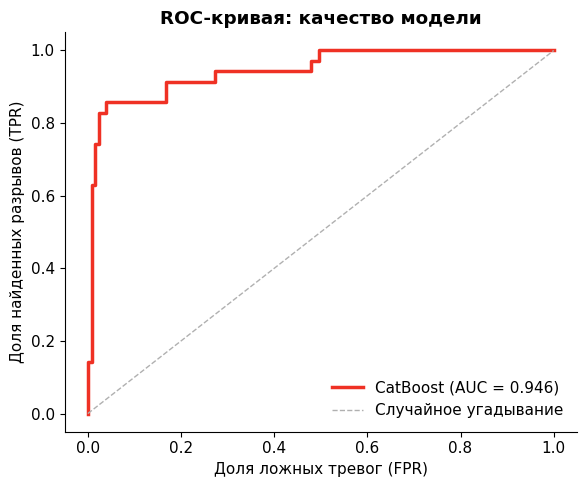

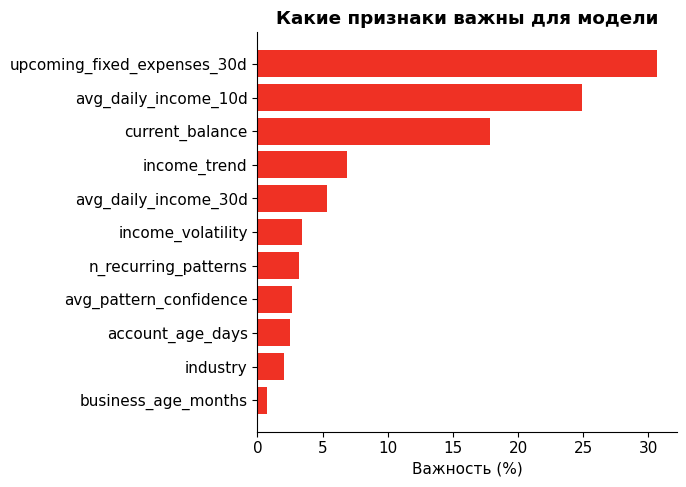

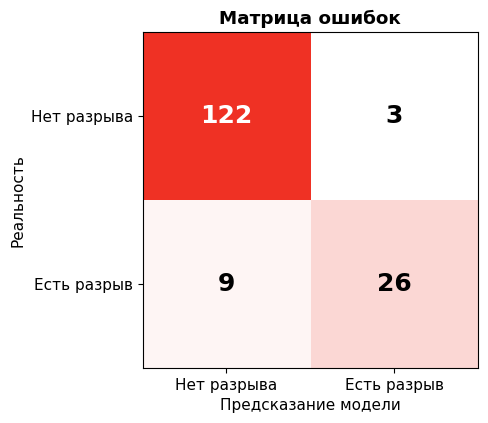

In [13]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

ALFA_RED = "#EF3124"
ALFA_BLACK = "#000000"
ALFA_GRAY = "#B0B0B0"

plt.rcParams.update({
    "text.color": ALFA_BLACK, "axes.labelcolor": ALFA_BLACK,
    "xtick.color": ALFA_BLACK, "ytick.color": ALFA_BLACK,
    "axes.edgecolor": ALFA_BLACK, "font.size": 11,
})

# --- график 1: ROC-кривая ---
fpr, tpr, _ = roc_curve(y_test, pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color=ALFA_RED, linewidth=2.5, label=f"CatBoost (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color=ALFA_GRAY, linestyle="--", linewidth=1, label="Случайное угадывание")
ax.set_xlabel("Доля ложных тревог (FPR)")
ax.set_ylabel("Доля найденных разрывов (TPR)")
ax.set_title("ROC-кривая: качество модели", fontweight="bold")
ax.legend(loc="lower right", frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# --- график 2: важность признаков ---
importance = catboost_model.get_feature_importance(prettified=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(importance["Feature Id"][::-1], importance["Importances"][::-1], color=ALFA_RED)
ax.set_xlabel("Важность (%)")
ax.set_title("Какие признаки важны для модели", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# --- график 3: матрица ошибок ---
alfa_cmap = LinearSegmentedColormap.from_list("alfa_red", ["#FFFFFF", ALFA_RED])
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(cm, cmap=alfa_cmap)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=18, fontweight="bold",
                color="white" if cm[i, j] > cm.max()/2 else ALFA_BLACK)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Нет разрыва", "Есть разрыв"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["Нет разрыва", "Есть разрыв"])
ax.set_xlabel("Предсказание модели")
ax.set_ylabel("Реальность")
ax.set_title("Матрица ошибок", fontweight="bold")
plt.tight_layout()
plt.show()